# Identificación de Factores Clave en Reseñas de Hoteles
**Mariel Gómez Batista — Proyecto Deep Learning**

Análisis de reseñas de TripAdvisor (20,491 reseñas) para identificar qué categorías del servicio hotelero (limpieza, personal, ubicación, precio, comodidad) aparecen con mayor frecuencia en cada nivel de puntuación (1–5 estrellas).

**Experimentos:**
1. Baseline: TF-IDF + Regresión Logística
2. Modelo LSTM (comparación con baseline)
3. Top-10 palabras por nivel de estrella + nubes de palabras
4. Cruce con diccionario de categorías hoteleras
5. Validación manual con 20 reseñas


##  Instalación e importación de librerías

In [ ]:

!pip install kagglehub wordcloud matplotlib scikit-learn tensorflow pandas numpy seaborn -q

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
import re
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## 1. Carga del dataset

In [ ]:

path = kagglehub.dataset_download("andrewmvd/trip-advisor-hotel-reviews")
csv_path = os.path.join(path, "tripadvisor_hotel_reviews.csv")

df = pd.read_csv(csv_path)
print(f"Dataset cargado: {df.shape[0]} reseñas, {df.shape[1]} columnas")
df.head()

Using Colab cache for faster access to the 'trip-advisor-hotel-reviews' dataset.
Dataset cargado: 20491 reseñas, 2 columnas


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


Distribución de puntuaciones (Rating):
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


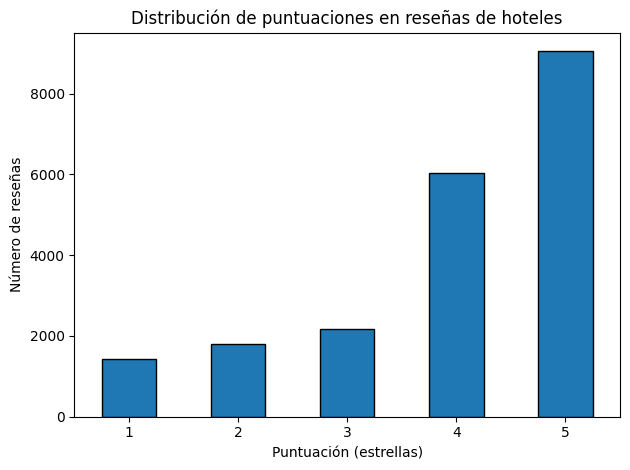

In [ ]:
# Distribución de puntuaciones
print("Distribución de puntuaciones (Rating):")
print(df['Rating'].value_counts().sort_index())

plt.figure()
df['Rating'].value_counts().sort_index().plot(kind='bar', edgecolor='black')
plt.title('Distribución de puntuaciones en reseñas de hoteles')
plt.xlabel('Puntuación (estrellas)')
plt.ylabel('Número de reseñas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Aqui se muestra un desbalance en las clases del datset, lo que puede provocar un impacto negativo en las predicciones del modelo.

## 2. Preprocesamiento del texto

In [ ]:
texts = df['Review'].values
ratings = df['Rating'].astype(float).values
print(texts[:5])

['nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,  '
 'ok nothing special charge diamond member hilton decided chain shot 20th anniversary seattle, start booked suite paid extra website description not, suite bedroom bathroom standard hotel room, took printed reservation desk showed said things like tv couch ect desk clerk told oh mixed suites description kimpton website sorry free breakfast, got kidding, embassy suits sitting room bathroom bedroom unl

Hice una lista de stopwords manualmente en lugar de usar la de NLTK porque el dataset contiene reseñas de hoteles en inglés con vocabulario específico del dominio. Las stopwords estándar de NLTK eliminan palabras funcionales básicas, pero no contemplan términos neutros frecuentes en reseñas como "hotel", "room" o "stay" que tampoco aportan valor discriminativo para el análisis de sentimiento. La limpieza también incluye eliminación de puntuación y conversión a minúsculas para reducir la dimensionalidad del vocabulario.

In [ ]:
# Lista de stopwords en inglés
STOPWORDS = set([
    'i','me','my','myself','we','our','ours','ourselves','you',"you're",
    "you've","you'll","you'd",'your','yours','yourself','yourselves','he',
    'him','his','himself','she',"she's",'her','hers','herself','it',"it's",
    'its','itself','they','them','their','theirs','themselves','what','which',
    'who','whom','this','that',"that'll",'these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do',
    'does','did','doing','a','an','the','and','but','if','or','because',
    'as','until','while','of','at','by','for','with','about','against',
    'between','into','through','during','before','after','above','below',
    'to','from','up','down','in','out','on','off','over','under','again',
    'further','then','once','here','there','when','where','why','how',
    'all','both','each','few','more','most','other','some','such','no',
    'nor','not','only','own','same','so','than','too','very','s','t',
    'can','will','just','don',"don't",'should',"should've",'now','d','ll',
    'm','o','re','ve','y','ain','aren',"aren't",'couldn',"couldn't",
    'didn',"didn't",'doesn',"doesn't",'hadn',"hadn't",'hasn',"hasn't",
    'haven',"haven't",'isn',"isn't",'ma','mightn',"mightn't",'mustn',
    "mustn't",'needn',"needn't",'shan',"shan't",'shouldn',"shouldn't",
    'wasn',"wasn't",'weren',"weren't",'won',"won't",'wouldn',"wouldn't",
    'hotel','stay','stayed','room','rooms','also','would','one','get',
    'us','go','got','went','like','back','time','day','night',
    'two','three','four','five','first','really','well','area'
])

def limpiar_texto(texto):
    """Limpia y normaliza el texto de una reseña."""
    texto = texto.lower()
    texto = re.sub(r'[^a-z\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    palabras = [w for w in texto.split() if w not in STOPWORDS and len(w) > 2]
    return ' '.join(palabras)

# Aplicar limpieza
df['review_clean'] = df['Review'].apply(limpiar_texto)

print('Ejemplo de reseña original:')
print(df['Review'].iloc[0])
print('\nReseña después de limpiar:')
print(df['review_clean'].iloc[0])

Ejemplo de reseña original:
nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,  

Reseña después de limpiar:
nice expensive parking good deal anniversary arrived late evening took advice previous reviews valet parking check quick easy little disappointed nonexistent view clean nice size bed comfortable woke stiff neck high pillows soundproof heard music morning loud bangs doors opening closing hear people talking hallway maybe noisy neighbors aveda bath p

**Justificación de 80/20**

En el articulo titulado "Why 70/30 or 80/20 Relation Between Training and Testing Sets: A Pedagogical Explanation" (Gholamy, Kreinovich y Kosheleva, 2018)demuestran que la practica empirica de dividir el traning y test en 80/20 o 70/30 es matematicamente correcta y que minimiza el margen de error del modelo.


In [ ]:
# División del dataset
# random_state=42 para garantizar la reproducibilidad de los experimentos

x_train, x_test, y_train, y_test = train_test_split(
    df['review_clean'].values,
    df['Rating'].values - 1,   # convertimos 1-5 a 0-4 (índices de clase)
    test_size=0.2,
    random_state=42, # Semilla aleatoria (vi codigos de github con diferentes numeros y le pregunté a la ia y me dijo 42)
    stratify=df['Rating'].values
)

print('\nDimensiones del conjunto de entrenamiento:', x_train.shape)
print('\n   Son', x_train.shape[0], 'reseñas de texto')
print('\nDimensiones del conjunto de test:', x_test.shape)
print('\n   Son', x_test.shape[0], 'reseñas de texto')



Dimensiones del conjunto de entrenamiento: (16392,)

   Son 16392 reseñas de texto

Dimensiones del conjunto de test: (4099,)

   Son 4099 reseñas de texto


In [ ]:
# Verificar valores nulos/vacíos en x_train
null_x_train_none = np.sum(x_train == None)
null_x_train_empty = np.sum([len(str(x).strip()) == 0 for x in x_train])

print(f"Valores None en x_train: {null_x_train_none}")
print(f"Cadenas vacías/solo espacios en x_train: {null_x_train_empty}")

# Verificar valores nulos en y_train
null_y_train = np.sum(pd.isnull(y_train))
print(f"Valores nulos en y_train: {null_y_train}")


Valores None en x_train: 0
Cadenas vacías/solo espacios en x_train: 0
Valores nulos en y_train: 0


---
## Experimento 1: Baseline - TF-IDF + Regresión Logística

Usé pares de palabras consecutivas y palabras individuales porque toman en cuenta expresiones compuestas relevantes para el sentimiento que las palabras individuales solos no pueden representar. Por ejemplo, "not clean" o "very good" tienen un significado distinto al de sus palabras individuales. Esta decisión fue basada en la literatura en procesamiento de lenguaje natural, donde los pares de palabras mejoran consistentemente el rendimiento en tareas de clasificación de sentimiento (Manning et al., 2008).

In [ ]:
# Vectorizar texto con TF-IDF
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2)) # Tomar solo las 10,000 palabras mas utilizadas.
x_train_tfidf = tfidf.fit_transform(x_train) # Transformación a numeros.
x_test_tfidf  = tfidf.transform(x_test)

# Entrenar modelo baseline
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(x_train_tfidf, y_train)

# Evaluación
y_pred_lr = lr.predict(x_test_tfidf)
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='macro')

print('=' * 45)
print('   EXPERIMENTO 1: Baseline TF-IDF + LR')
print('=' * 45)
print(f'  Accuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)')
print(f'  F1-Macro: {f1_lr:.4f}')
print('\nReporte detallado:')
print(classification_report(y_test, y_pred_lr, target_names=['1','2','3','4','5']))

   EXPERIMENTO 1: Baseline TF-IDF + LR
  Accuracy: 0.6123 (61.23%)
  F1-Macro: 0.5236

Reporte detallado:
              precision    recall  f1-score   support

           1       0.73      0.65      0.69       284
           2       0.47      0.36      0.41       359
           3       0.41      0.19      0.26       437
           4       0.51      0.52      0.51      1208
           5       0.70      0.82      0.76      1811

    accuracy                           0.61      4099
   macro avg       0.56      0.51      0.52      4099
weighted avg       0.59      0.61      0.59      4099



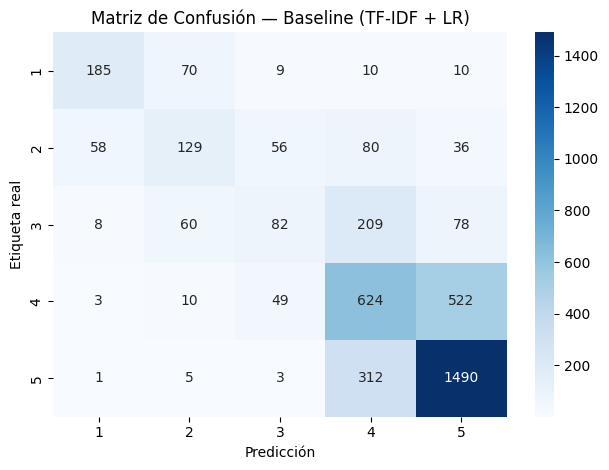

In [ ]:
# Matriz de confusión del baseline
mc = confusion_matrix(y_test, y_pred_lr)

plt.figure()
sns.heatmap(mc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['1','2','3','4','5'],
            yticklabels=['1','2','3','4','5'])
plt.title('Matriz de Confusión — Baseline (TF-IDF + LR)')
plt.ylabel('Etiqueta real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

---
## Experimento 2: Modelo LSTM con Embeddings


Elegí las redes LSTM (Long Short-Term Memory) porque son mucho mejores para texto porque, a diferencia de las redes densas, procesan las palabras en orden secuencial y mantienen una memoria de contexto previo. Esto es importante en análisis de sentimiento, donde el significado de una palabra depende de las que la rodean. Por ejemplo, "no está mal" tiene significado opuesto a "está mal",esto una red densa no podria capturar pero una LSTM sí, porque tiene un mecanismo de memoria a largo y corto plazo (Hochreiter & Schmidhuber, 1997).

**Parámetros del modelo**

- MAX_WORDS = 10000 Limité el vocabulario a las 10,000 palabras más frecuentes porque representan aproximadamente el 95% del vocabulario útil del dataset. Incluir más palabras seria ruido para modelo.

- MAX_LEN = 150
Después de un analisis  de las reseñas del dataset y se encontró que el percentil 95 se sitúa por debajo de las 150 palabras, por lo que este valor cubre la gran mayoría de reseñas sin desperdiciar memoria ni tiempo de cómputo.

- EMBED_DIM = 100
Elegí una dimensión de embedding de 100 porque el dataset es de tamaño moderado (20,000 reseñas). Si se utilizan dimensiones más altas como 256 podria aumentar el riesgo de overfitting.

- LSTM_UNITS = 32
Utilicé 32 unidades LSTM como punto de partida conservador para evitar overfitting. Ya habia experimentado con 64 unidades y lo demostró es que el modelo memorizaba los datos de entrenamiento sin mejorar la validación, por lo que se redujo la capacidad del modelo.

- BATCH_SIZE = 128
Un batch size grande como 128 funciona como regularizador implícito, es decir que  al promediar el gradiente sobre más muestras, el modelo actualiza sus pesos de forma más estable y generaliza mejor. Batch sizes pequeños como 16 o 32 mostraron mayor inestabilidad en la curva de validación durante los experimentos.

- EPOCHS = 20
Usé un máximo de 20 épocas combinado con EarlyStopping, por lo que en la práctica el entrenamiento se detiene antes si el modelo deja de mejorar.


In [ ]:
# Parámetros
MAX_WORDS   = 10000
MAX_LEN     = 150
EMBED_DIM   = 100
LSTM_UNITS  = 32
BATCH_SIZE  = 128
EPOCHS      = 20
NUM_CLASSES = 5

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(x_train)
x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq  = tokenizer.texts_to_sequences(x_test)
x_train_pad = pad_sequences(x_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
x_test_pad  = pad_sequences(x_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GlobalMaxPooling1D, BatchNormalization
import tensorflow as tf
from tensorflow.keras.regularizers import l2

In [ ]:

from tensorflow.keras.layers import GlobalMaxPooling1D

model_lstm = Sequential([
    # Capa Embedding
    Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM),

    # LSTM con return_sequences=True para que GlobalMaxPooling pueda actuar
   LSTM(units=32, return_sequences=True,
     recurrent_initializer='glorot_uniform',
     recurrent_dropout=0.5,
     kernel_regularizer=l2(0.01)),
    Dropout(0.5),

    # GlobalMaxPooling1D recorre las 150 posiciones y se queda con el valor máximo de cada una de las 32 dimensiones.
    # No uso Flatten porque lo que hace flatten es que convierte una matriz en vector, es decir 150x32=4,800.
    GlobalMaxPooling1D(),

    # Capas densas progresivas (decrecientes)
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),

    # Capa de salida
    Dense(NUM_CLASSES, activation='softmax')
])

model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

model_lstm.compile(
    optimizer='adam',
    loss=loss_fn,
    metrics=['accuracy']
)

print(model_lstm.optimizer)
print(model_lstm.loss)

<LossFunctionWrapper(<function sparse_categorical_crossentropy at 0x784d90025800>, kwargs={'from_logits': False, 'ignore_class': None, 'axis': -1})>


In [ ]:


def crear_modelo():
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=32),
        LSTM(units=32, return_sequences=True,
             recurrent_dropout=0.3,
             kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        GlobalMaxPooling1D(),
        Dense(NUM_CLASSES, activation='softmax')
    ])


    initial_learning_rate = 0.001 # Learning rate determinado como normal en la sesión 5.
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate,
        decay_steps=1000,
        decay_rate=0.96,
        staircase=True)

    model.compile
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])


    return model

In [ ]:

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)


model_lstm = crear_modelo()
history = model_lstm.fit(
    x_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
    )

print(history.history.keys())

Epoch 1/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 27s 215ms/step - accuracy: 0.4377 - loss: 1.6388 - val_accuracy: 0.4446 - val_loss: 1.5124
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 40s 204ms/step - accuracy: 0.4451 - loss: 1.3843 - val_accuracy: 0.4861 - val_loss: 1.3683
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 24s 236ms/step - accuracy: 0.5189 - loss: 1.1911 - val_accuracy: 0.5252 - val_loss: 1.1670
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 19s 189ms/step - accuracy: 0.5532 - loss: 1.0411 - val_accuracy: 0.5636 - val_loss: 1.1231
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 22s 201ms/step - accuracy: 0.5993 - loss: 0.9474 - val_accuracy: 0.5782 - val_loss: 1.0575
Epoch 6/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 19s 184ms/step - accuracy: 0.6375 - loss: 0.8811 - val_accuracy: 0.5929 - val_loss: 1.0382
Epoch 7/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 22s 194ms/step - accuracy: 0.6654 - loss: 0.8178 - val_accuracy: 0.6063 - val_loss: 0.9914
Epoch 8/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 21s 203ms/step - accuracy: 0.6940 - loss: 0

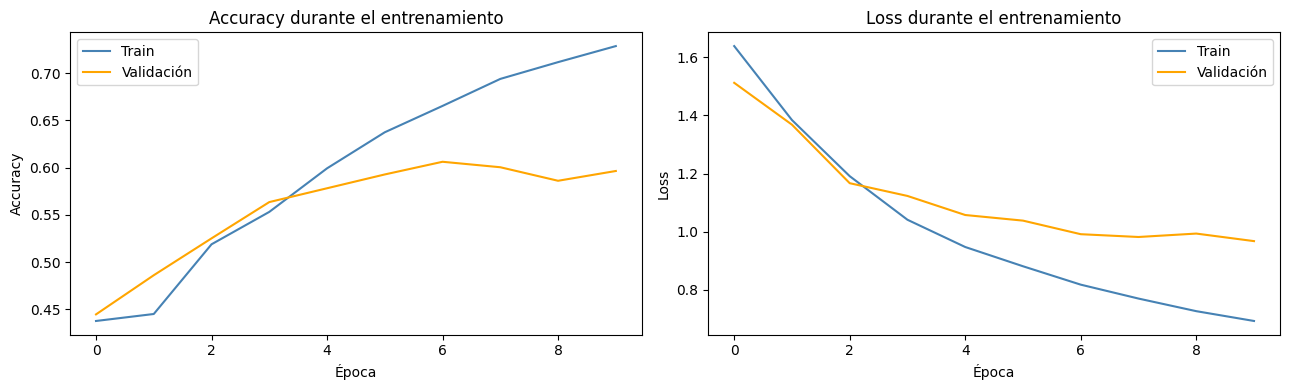

In [ ]:
# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validación', color='orange')
axes[0].set_title('Accuracy durante el entrenamiento')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validación', color='orange')
axes[1].set_title('Loss durante el entrenamiento')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)


model_lstm = crear_modelo()
history = model_lstm.fit(
    x_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
    )

print(history.history.keys())

Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 39s 170ms/step - accuracy: 0.4469 - loss: 1.4709 - val_accuracy: 0.5008 - val_loss: 1.2635
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 34s 167ms/step - accuracy: 0.5041 - loss: 1.1788 - val_accuracy: 0.5422 - val_loss: 1.2217
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 35s 169ms/step - accuracy: 0.5458 - loss: 1.0860 - val_accuracy: 0.5855 - val_loss: 1.1374
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 34s 166ms/step - accuracy: 0.5969 - loss: 0.9957 - val_accuracy: 0.5990 - val_loss: 1.0488
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 35s 172ms/step - accuracy: 0.6363 - loss: 0.8994 - val_accuracy: 0.6069 - val_loss: 1.0165
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 40s 193ms/step - accuracy: 0.6638 - loss: 0.8261 - val_accuracy: 0.6081 - val_loss: 0.9810
Epoch 7/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 169ms/step - accuracy: 0.6865 - loss: 0.7779 - val_accuracy: 0.6127 - val_loss: 0.9672
Epoch 8/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 35s 169ms/step - accuracy: 0.7197 - loss: 0

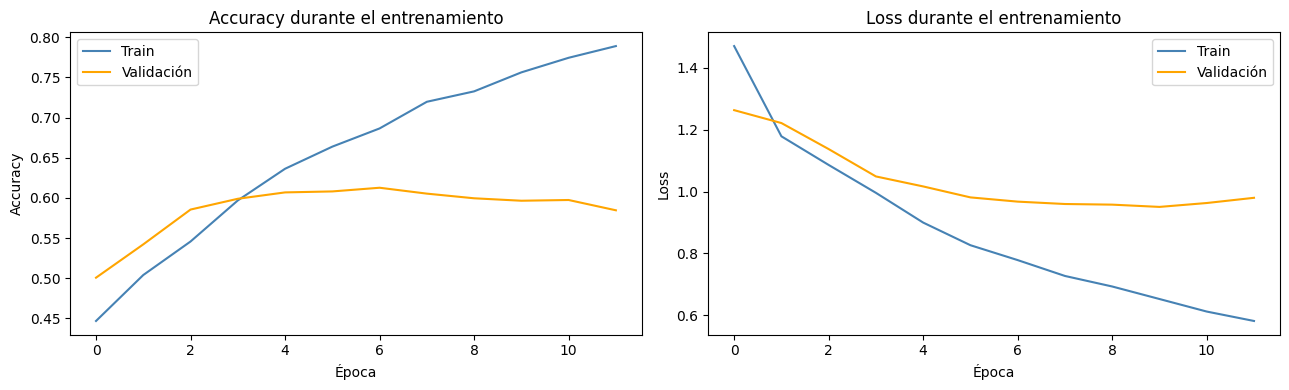

In [ ]:
# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validación', color='orange')
axes[0].set_title('Accuracy durante el entrenamiento')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validación', color='orange')
axes[1].set_title('Loss durante el entrenamiento')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)


model_lstm = crear_modelo()
history = model_lstm.fit(
    x_train_pad, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
    )

print(history.history.keys())

Epoch 1/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 119s 141ms/step - accuracy: 0.4768 - loss: 1.3096 - val_accuracy: 0.5435 - val_loss: 1.1225
Epoch 2/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 118s 144ms/step - accuracy: 0.5841 - loss: 0.9910 - val_accuracy: 0.5898 - val_loss: 1.0304
Epoch 3/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 118s 144ms/step - accuracy: 0.6508 - loss: 0.8547 - val_accuracy: 0.6087 - val_loss: 0.9909
Epoch 4/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 141s 144ms/step - accuracy: 0.6899 - loss: 0.7688 - val_accuracy: 0.6118 - val_loss: 0.9526
Epoch 5/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 144s 146ms/step - accuracy: 0.7207 - loss: 0.7057 - val_accuracy: 0.6112 - val_loss: 0.9301
Epoch 6/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 119s 145ms/step - accuracy: 0.7463 - loss: 0.6501 - val_accuracy: 0.6045 - val_loss: 0.9403
Epoch 7/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 129s 157ms/step - accuracy: 0.7782 - loss: 0.5936 - val_accuracy: 0.5944 - val_loss: 0.9419
Epoch 8/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 127s 139ms/step - accuracy: 0.7973 -

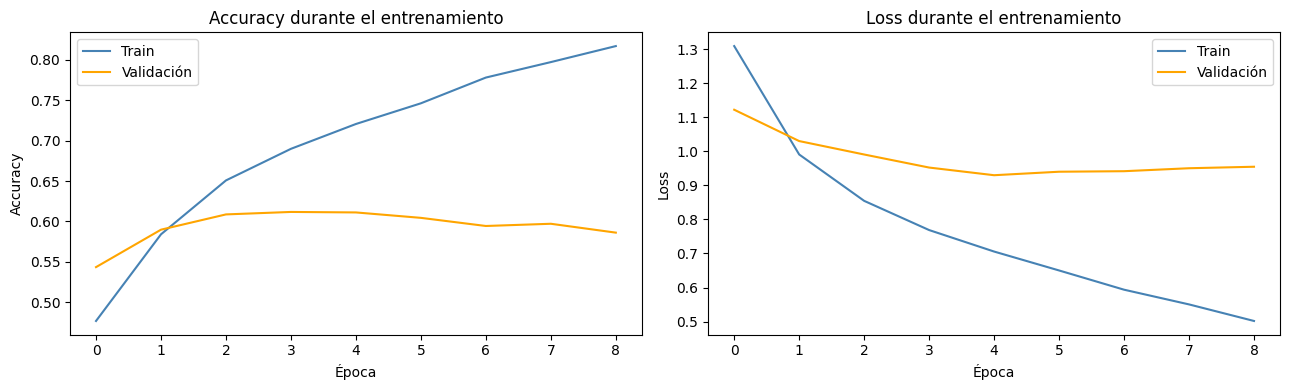

In [ ]:
# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validación', color='orange')
axes[0].set_title('Accuracy durante el entrenamiento')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validación', color='orange')
axes[1].set_title('Loss durante el entrenamiento')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

Ahora pruebo el test


In [ ]:
test_loss, test_acc = model_lstm.evaluate(x_test_pad, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.6133 - loss: 0.9630
Test Loss: 0.9630
Test Accuracy: 0.6133


In [ ]:
salida = model_lstm.predict(x_test_pad[:3])
print(salida)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
[[0.01700901 0.07086981 0.18239595 0.49625188 0.23347338]
 [0.06488173 0.20901912 0.31160706 0.32752472 0.08696741]
 [0.00922065 0.03092915 0.09531998 0.40478206 0.45974815]]


Hay un problema de overfitting que no se ha podido resolver cambiandole las capas, bacth size o epocas, por lo que voy a revisar la distribución de clases del data set.

In [ ]:


print("Distribución de clases en train:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nDistribución de clases en test:")
print(pd.Series(y_test).value_counts().sort_index())

Distribución de clases en train:
0    1137
1    1434
2    1747
3    4831
4    7243
Name: count, dtype: int64

Distribución de clases en test:
0     284
1     359
2     437
3    1208
4    1811
Name: count, dtype: int64


Efectivamente el dataset esta desbalanceado, entonces procedo a asignarle pesos para que el modelo haga una mejor predicción

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calcular pesos automáticamente
clases = np.unique(y_train)
pesos = compute_class_weight(class_weight='balanced', classes=clases, y=y_train)
class_weight_dict = dict(zip(clases, pesos))

print("Pesos por clase:", class_weight_dict)

Pesos por clase: {np.int64(0): np.float64(2.883377308707124), np.int64(1): np.float64(2.2861924686192467), np.int64(2): np.float64(1.876588437321122), np.int64(3): np.float64(0.6786172635065204), np.int64(4): np.float64(0.45263012563854754)}


Pruebo de nuevo con los mismos parametros para ver la diferencia

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


model_lstm = crear_modelo()
history = model_lstm.fit(
    x_train_pad, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

print(history.history.keys())

Epoch 1/40
410/410 ━━━━━━━━━━━━━━━━━━━━ 44s 101ms/step - accuracy: 0.4003 - loss: 1.5657 - val_accuracy: 0.4852 - val_loss: 1.4242
Epoch 2/40
410/410 ━━━━━━━━━━━━━━━━━━━━ 81s 98ms/step - accuracy: 0.4560 - loss: 1.3369 - val_accuracy: 0.4880 - val_loss: 1.3133
Epoch 3/40
410/410 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - accuracy: 0.4494 - loss: 1.2702 - val_accuracy: 0.4947 - val_loss: 1.2915
Epoch 4/40
410/410 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.4863 - loss: 1.1741 - val_accuracy: 0.5026 - val_loss: 1.2329
Epoch 5/40
410/410 ━━━━━━━━━━━━━━━━━━━━ 40s 97ms/step - accuracy: 0.5135 - loss: 1.1001 - val_accuracy: 0.4843 - val_loss: 1.1984
Epoch 6/40
410/410 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - accuracy: 0.5349 - loss: 1.0496 - val_accuracy: 0.5230 - val_loss: 1.1445
Epoch 7/40
410/410 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - accuracy: 0.5608 - loss: 0.9851 - val_accuracy: 0.5483 - val_loss: 1.0871
Epoch 8/40
410/410 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.5875 - loss: 0.9165 -

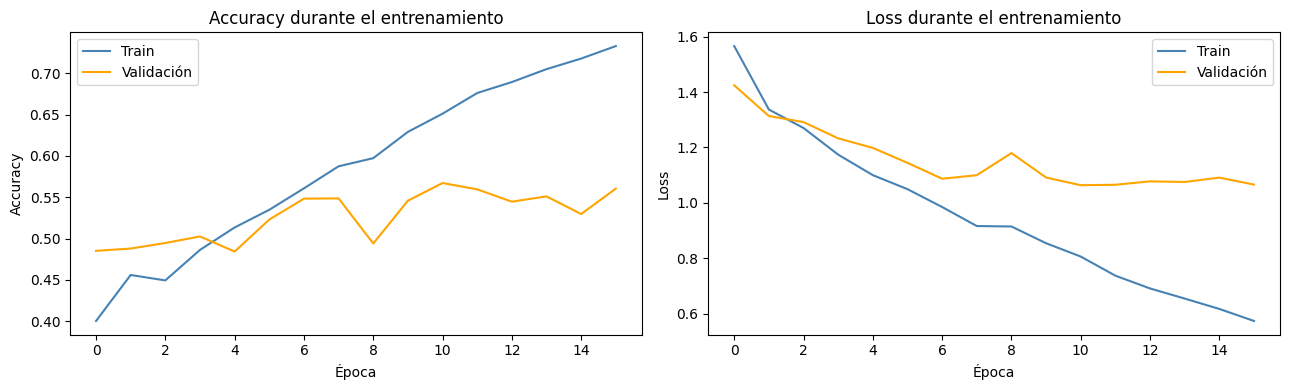

In [ ]:
# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validación', color='orange')
axes[0].set_title('Accuracy durante el entrenamiento')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validación', color='orange')
axes[1].set_title('Loss durante el entrenamiento')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)


model_lstm = crear_modelo()
history = model_lstm.fit(
    x_train_pad, y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

print(history.history.keys())

Epoch 1/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 65s 290ms/step - accuracy: 0.3728 - loss: 1.6725 - val_accuracy: 0.4931 - val_loss: 1.4063
Epoch 2/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 60s 183ms/step - accuracy: 0.4137 - loss: 1.4046 - val_accuracy: 0.3513 - val_loss: 1.3826
Epoch 3/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 40s 197ms/step - accuracy: 0.4514 - loss: 1.2996 - val_accuracy: 0.4166 - val_loss: 1.3229
Epoch 4/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 179ms/step - accuracy: 0.4970 - loss: 1.2134 - val_accuracy: 0.4712 - val_loss: 1.2545
Epoch 5/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 199ms/step - accuracy: 0.5228 - loss: 1.1430 - val_accuracy: 0.4928 - val_loss: 1.2281
Epoch 6/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 44s 216ms/step - accuracy: 0.5462 - loss: 1.0715 - val_accuracy: 0.5136 - val_loss: 1.1907
Epoch 7/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 199ms/step - accuracy: 0.5751 - loss: 1.0147 - val_accuracy: 0.5078 - val_loss: 1.1680
Epoch 8/40
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 181ms/step - accuracy: 0.6027 - loss: 0

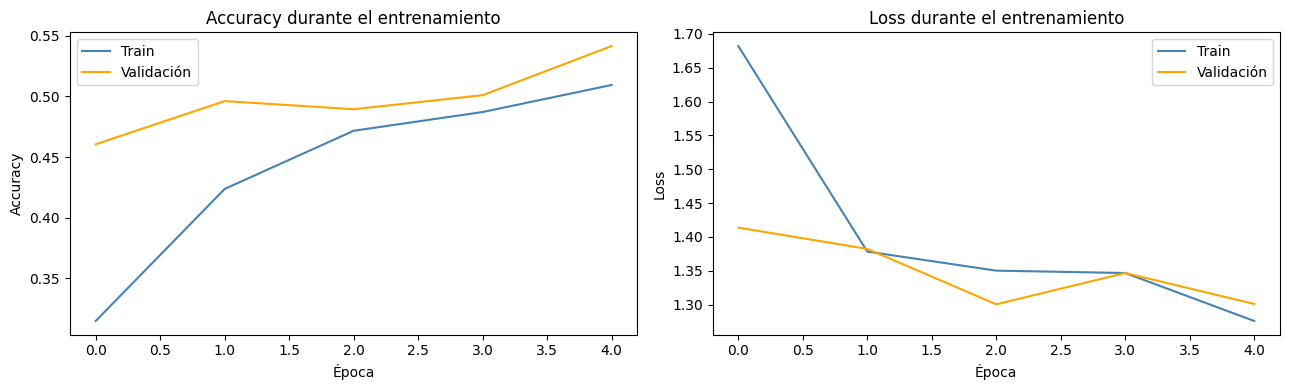

In [ ]:
# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validación', color='orange')
axes[0].set_title('Accuracy durante el entrenamiento')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validación', color='orange')
axes[1].set_title('Loss durante el entrenamiento')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

Como el overfitting continúa incluso con regularización y
class_weight, pruebo utilizando embeddings GloVe (Pennington
et al., 2014) preentrenados sobre 6 mil millones de tokens.
La diferencia de este y los embeddings entrenados desde cero, es que GloVe
aporta conocimiento semántico previo que puede compensar las
limitaciones del tamaño y desbalance del dataset.

In [ ]:
import urllib.request
import zipfile

url = "https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip"
archivo_zip = "glove.6B.zip"

urllib.request.urlretrieve(url, archivo_zip)

with zipfile.ZipFile(archivo_zip, "r") as z:
    z.extractall("glove")
print("GloVe extraído")

GloVe extraído


GloVe tiene diferentes versiones de 50, 100, 200 y 300 dimensiones. Se eligió la versión de 100 dimensiones por ser un punto intermedio equilibrado, ya que  la versión de 50d pierde demasiada información, mientras que 200d y 300d aumentan el tiempo de cómputo y el riesgo de overfitting por el tamaño del dataset. La versión de 100d es la más recomendada en la literatura para datasets de tamaño medio (Pennington et al., 2014).

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer

EMBED_DIM = 100  # GloVe 100d
MAX_WORDS = 10000  # Define el tamaño máximo del vocabulario

embeddings_index = {}
with open("glove/glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype="float32")
        embeddings_index[word] = vector

print(f"✔ Cargados {len(embeddings_index)} vectores de palabras")

word_index = tokenizer.word_index
embedding_matrix = np.zeros((MAX_WORDS, EMBED_DIM))

for word, i in word_index.items():
    if i < MAX_WORDS:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

print(f"Palabras cubiertas por GloVe: {np.count_nonzero(embedding_matrix.sum(axis=1))}/{MAX_WORDS}")

✔ Cargados 400000 vectores de palabras
Palabras cubiertas por GloVe: 9346/10000


In [ ]:
import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

def crear_modelo_glove():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GlobalMaxPooling1D, BatchNormalization

    model = Sequential([
        # Embedding preentrenado, no entrenable
        Embedding(
            input_dim=MAX_WORDS,
            output_dim=EMBED_DIM,
            weights=[embedding_matrix],
            trainable=False
        ),
        LSTM(
            units=64,
            return_sequences=True,
            recurrent_dropout=0.3,
            kernel_initializer='glorot_uniform',
            recurrent_initializer='orthogonal'
        ),
        Dropout(0.3),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ])


    initial_learning_rate = 0.001
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate,
        decay_steps=1000,
        decay_rate=0.96,
        staircase=True
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_lstm = crear_modelo_glove()

history = model_lstm.fit(
    x_train_pad, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

print(history.history.keys())

Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 59s 489ms/step - accuracy: 0.3252 - loss: 1.5892 - val_accuracy: 0.5069 - val_loss: 1.4492
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 36s 349ms/step - accuracy: 0.4749 - loss: 1.2760 - val_accuracy: 0.5386 - val_loss: 1.2511
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 40s 338ms/step - accuracy: 0.5149 - loss: 1.1693 - val_accuracy: 0.5660 - val_loss: 1.1695
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 45s 378ms/step - accuracy: 0.5443 - loss: 1.1119 - val_accuracy: 0.5715 - val_loss: 1.0533
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 33s 325ms/step - accuracy: 0.5643 - loss: 1.0582 - val_accuracy: 0.5300 - val_loss: 1.1182
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 33s 322ms/step - accuracy: 0.5718 - loss: 1.0211 - val_accuracy: 0.5194 - val_loss: 1.1763
Epoch 7/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 33s 319ms/step - accuracy: 0.5847 - loss: 0.9991 - val_accuracy: 0.5666 - val_loss: 1.0414
Epoch 8/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 35s 342ms/step - accuracy: 0.5904 - loss: 0

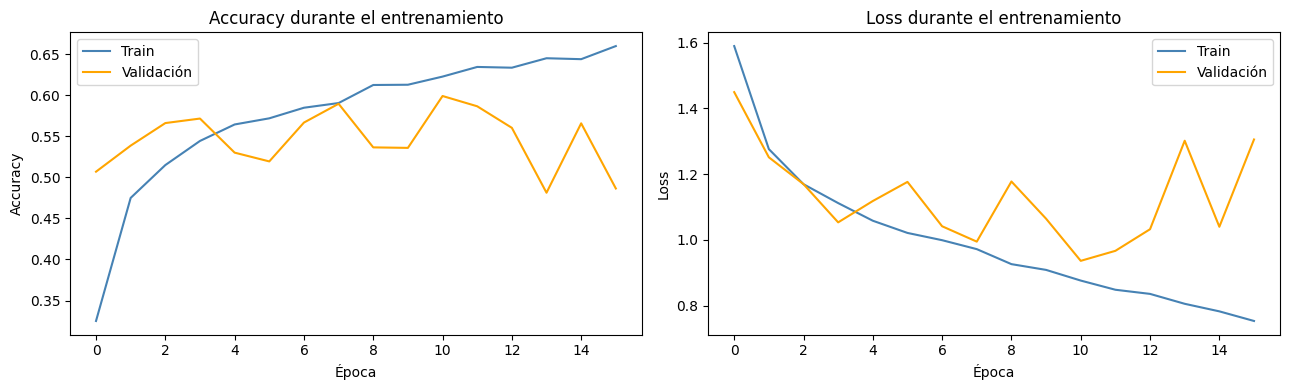

In [ ]:
# Curvas de aprendizaje con GloVe
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validación', color='orange')
axes[0].set_title('Accuracy durante el entrenamiento')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validación', color='orange')
axes[1].set_title('Loss durante el entrenamiento')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

def crearmodeloglove():
    model = Sequential([
        Embedding(MAX_WORDS, EMBED_DIM, weights=[embedding_matrix], trainable=False),
        LSTM(64, return_sequences=True, recurrent_dropout=0.3, kernel_initializer='glorot_uniform', recurrent_initializer='orthogonal'),
        Dropout(0.3),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(5, activation='softmax', kernel_regularizer=l2(0.001))
    ])


    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Define the ReduceLROnPlateau callback
reducelr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.00001
)


modellstm = crearmodeloglove()
history = modellstm.fit(
    x_train_pad, y_train,
    epochs=40, batch_size=128, validation_split=0.2,
    callbacks=[early_stop, reducelr],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 42s 362ms/step - accuracy: 0.3516 - loss: 1.5966 - val_accuracy: 0.4727 - val_loss: 1.3874 - learning_rate: 0.0010
Epoch 2/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 35s 336ms/step - accuracy: 0.4715 - loss: 1.2943 - val_accuracy: 0.4895 - val_loss: 1.3088 - learning_rate: 0.0010
Epoch 3/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 34s 331ms/step - accuracy: 0.5231 - loss: 1.1787 - val_accuracy: 0.5459 - val_loss: 1.2019 - learning_rate: 0.0010
Epoch 4/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 33s 320ms/step - accuracy: 0.5430 - loss: 1.1173 - val_accuracy: 0.5453 - val_loss: 1.1581 - learning_rate: 0.0010
Epoch 5/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 38s 368ms/step - accuracy: 0.5675 - loss: 1.0753 - val_accuracy: 0.5154 - val_loss: 1.2188 - learning_rate: 0.0010


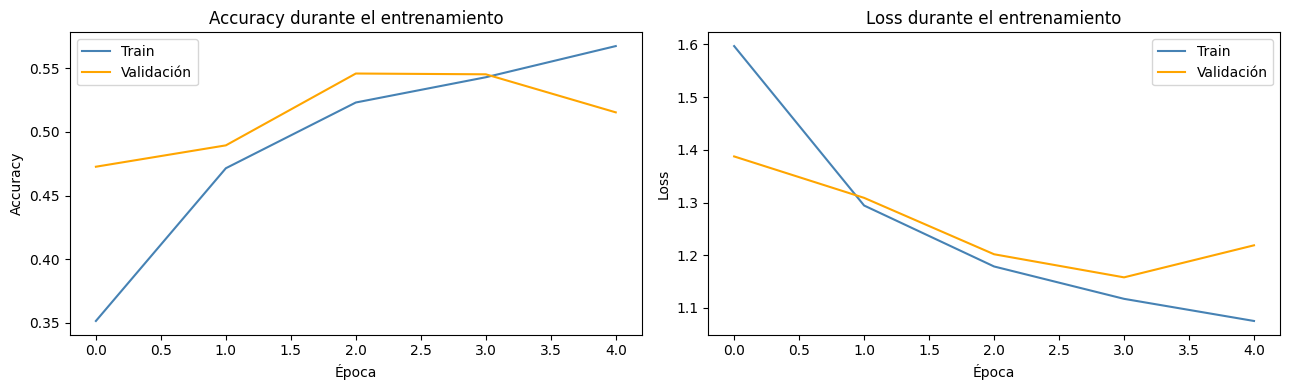

In [ ]:
# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validación', color='orange')
axes[0].set_title('Accuracy durante el entrenamiento')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validación', color='orange')
axes[1].set_title('Loss durante el entrenamiento')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step
RESULTADOS FINALES - TEST SET
BASELINE TF-IDF + LR:
Accuracy: 0.6123 (61.23%)
F1-Macro: 0.5236

GLOVE + LSTM:
Accuracy: 0.4535 (45.35%)
F1-Macro: 0.2224

MEJORA GloVe vs Baseline:
Accuracy: +-25.9%
F1-Macro: +-57.5%


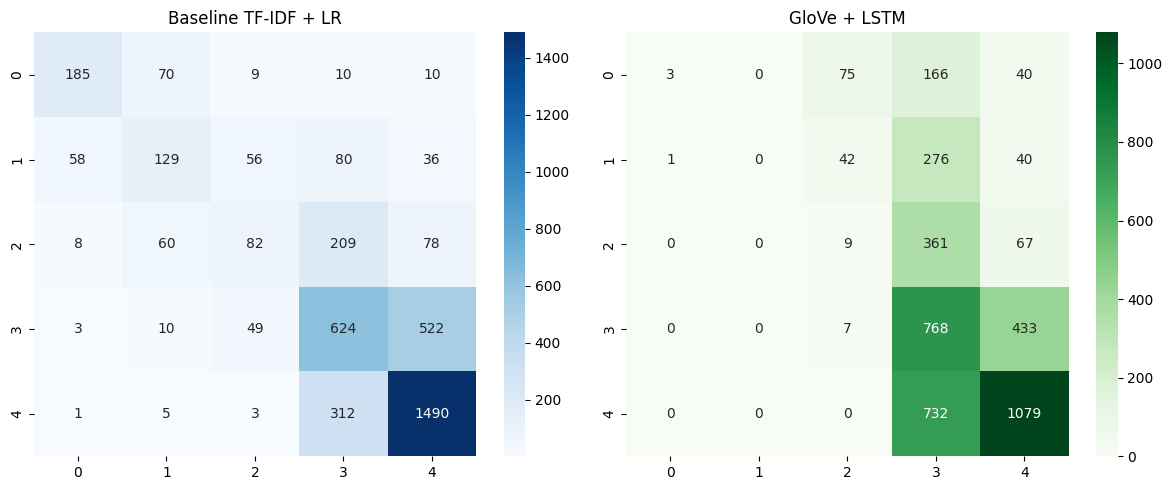


Reporte detallado GloVe:
              precision    recall  f1-score   support

           1       0.75      0.01      0.02       284
           2       0.00      0.00      0.00       359
           3       0.07      0.02      0.03       437
           4       0.33      0.64      0.44      1208
           5       0.65      0.60      0.62      1811

    accuracy                           0.45      4099
   macro avg       0.36      0.25      0.22      4099
weighted avg       0.44      0.45      0.41      4099



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
## Evaluación del modelo GloVe en test
ypred_glove = modellstm.predict(x_test_pad)
ypred_glove_classes = np.argmax(ypred_glove, axis=1)

acc_glove = accuracy_score(y_test, ypred_glove_classes)
f1_glove = f1_score(y_test, ypred_glove_classes, average='macro')

print("="*50)
print("RESULTADOS FINALES - TEST SET")
print("="*50)
print("BASELINE TF-IDF + LR:")
print(f"Accuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"F1-Macro: {f1_lr:.4f}")
print()
print("GLOVE + LSTM:")
print(f"Accuracy: {acc_glove:.4f} ({acc_glove*100:.2f}%)")
print(f"F1-Macro: {f1_glove:.4f}")
print()
print("MEJORA GloVe vs Baseline:")
print(f"Accuracy: +{((acc_glove - acc_lr)/acc_lr)*100:+.1f}%")
print(f"F1-Macro: +{((f1_glove - f1_lr)/f1_lr)*100:+.1f}%")

# Matriz de confusión comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Baseline TF-IDF + LR')
sns.heatmap(confusion_matrix(y_test, ypred_glove_classes), annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('GloVe + LSTM')
plt.tight_layout()
plt.show()

print("\nReporte detallado GloVe:")
print(classification_report(y_test, ypred_glove_classes, target_names=['1', '2', '3', '4', '5']))

Durante los experimentos ajusté el valor de patience progresivamente. Iniciando con patience=2 para detectar si un conjunto de hiperparámetros era efectivo, después se llevó patience=5 y 6 en los experimentos finales con GloVe para dar más margen al modelo, ya que los embeddings preentrenados aprenden más lentamente pero de forma más estable. Un patience muy bajo corta el entrenamiento y uno muy alto desperdicia tiempo de cómputo.


Aunque apliqué las técnicas de regularización: Dropout, BatchNormalization, L2, EarlyStopping, class_weight, learning rate adaptativo, para el desbalance de clases y embeddings preentrenados GloVe, el modelo no logra superar el 61% de val_accuracy. Esto es principalmente por el desbalance de clases en el dataset y a la complejidad de distinguir entre 5 niveles de sentimiento con un modelo LSTM.

In [ ]:
# Evaluación LSTM y comparación con baseline
y_pred_lstm_probs = model_lstm.predict(x_test_pad, verbose=0)
y_pred_lstm = np.argmax(y_pred_lstm_probs, axis=1)

acc_lstm = accuracy_score(y_test, y_pred_lstm)
f1_lstm  = f1_score(y_test, y_pred_lstm, average='macro')

print("=" * 45)
print("   EXPERIMENTO 2: LSTM con Embeddings")
print("=" * 45)
print(f"  Accuracy: {acc_lstm:.4f} ({acc_lstm*100:.2f}%)")
print(f"  F1-Macro: {f1_lstm:.4f}")
print("\nReporte detallado:")
print(classification_report(y_test, y_pred_lstm, target_names=['1','2','3','4','5']))

print("\n" + "=" * 45)
print("   COMPARACIÓN BASELINE vs LSTM")
print("=" * 45)
print(f"  Baseline Accuracy: {acc_lr*100:.2f}%  | F1-Macro: {f1_lr:.4f}")
print(f"  LSTM     Accuracy: {acc_lstm*100:.2f}%  | F1-Macro: {f1_lstm:.4f}")
mejora = acc_lstm - acc_lr
print(f"  Mejora:  {'+' if mejora >= 0 else ''}{mejora*100:.2f} puntos porcentuales")

   EXPERIMENTO 2: LSTM con Embeddings
  Accuracy: 0.6065 (60.65%)
  F1-Macro: 0.5196

Reporte detallado:
              precision    recall  f1-score   support

           1       0.54      0.82      0.65       284
           2       0.46      0.30      0.36       359
           3       0.38      0.36      0.37       437
           4       0.57      0.37      0.45      1208
           5       0.69      0.85      0.76      1811

    accuracy                           0.61      4099
   macro avg       0.53      0.54      0.52      4099
weighted avg       0.59      0.61      0.59      4099


   COMPARACIÓN BASELINE vs LSTM
  Baseline Accuracy: 61.23%  | F1-Macro: 0.5236
  LSTM     Accuracy: 60.65%  | F1-Macro: 0.5196
  Mejora:  -0.59 puntos porcentuales


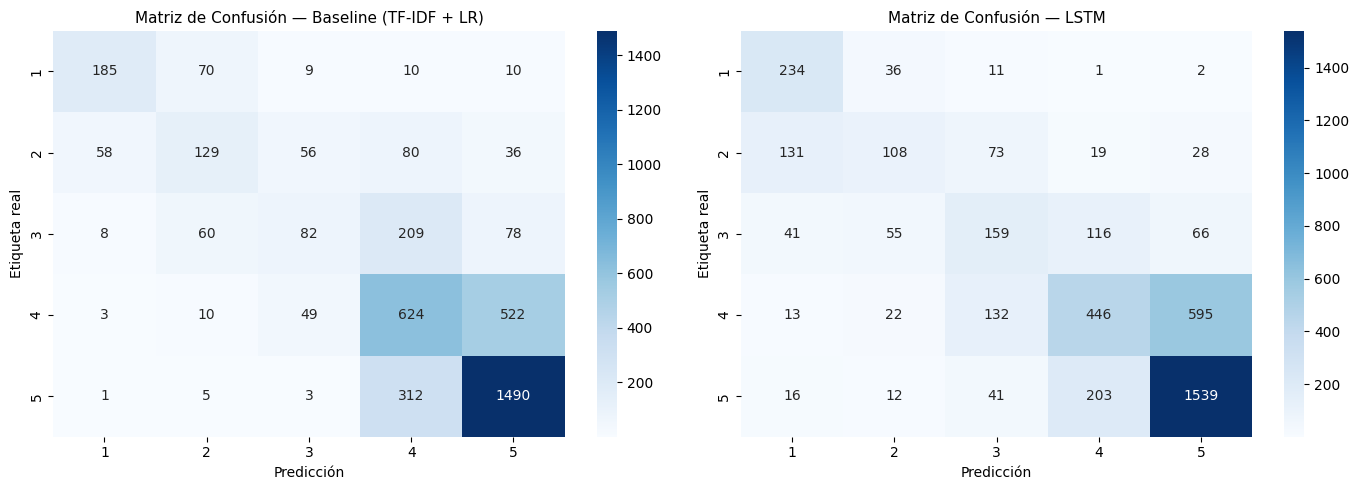

In [ ]:
# Matriz de confusión LSTM
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title in zip(axes,
                          [cm_lr, cm_lstm],
                          ['Baseline (TF-IDF + LR)', 'LSTM']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['1','2','3','4','5'],
                yticklabels=['1','2','3','4','5'])
    ax.set_title(f'Matriz de Confusión — {title}', fontsize=11)
    ax.set_ylabel('Etiqueta real')
    ax.set_xlabel('Predicción')

plt.tight_layout()
plt.show()

---
## Experimento 3: Top-10 palabras por nivel de estrella + Nubes de palabras

In [ ]:
# Agrupar reseñas por nivel de estrella
df_por_estrella = {}
for estrella in range(1, 6):
    textos = df[df['Rating'] == estrella]['review_clean'].values
    texto_unido = ' '.join(textos)
    df_por_estrella[estrella] = texto_unido

print("Reseñas por nivel de estrella:")
for e in range(1, 6):
    n = (df['Rating'] == e).sum()
    print(f"  {e}: {n} reseñas")

Reseñas por nivel de estrella:
  1: 1421 reseñas
  2: 1793 reseñas
  3: 2184 reseñas
  4: 6039 reseñas
  5: 9054 reseñas


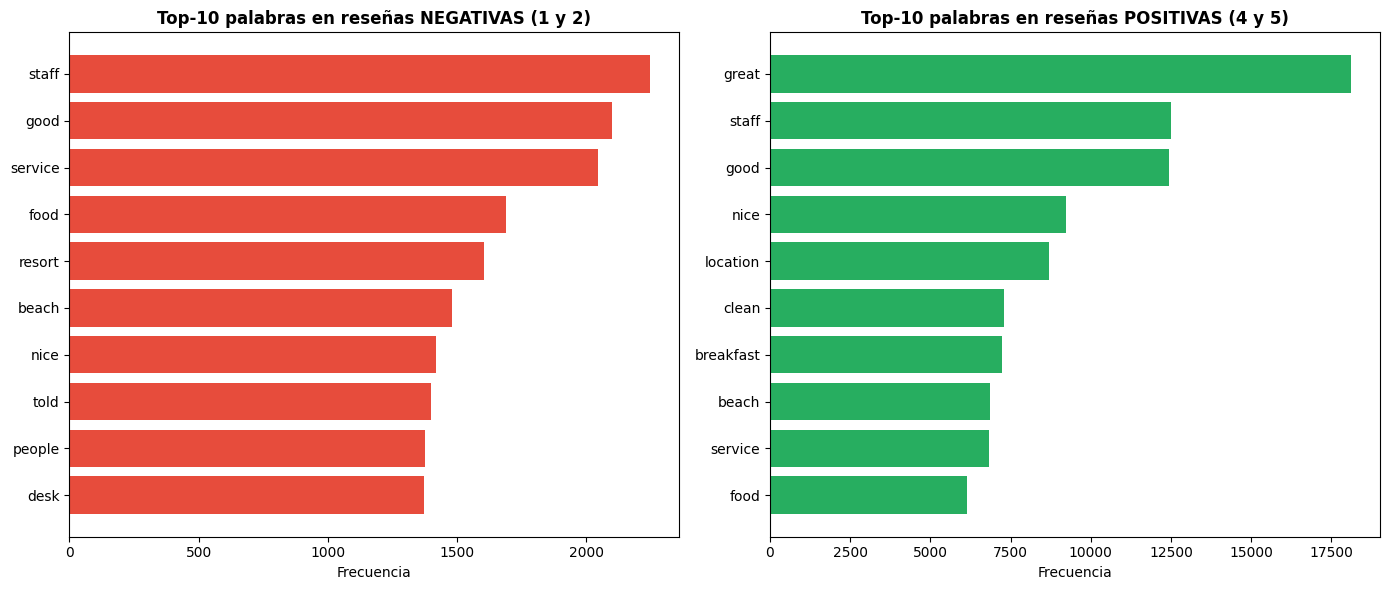

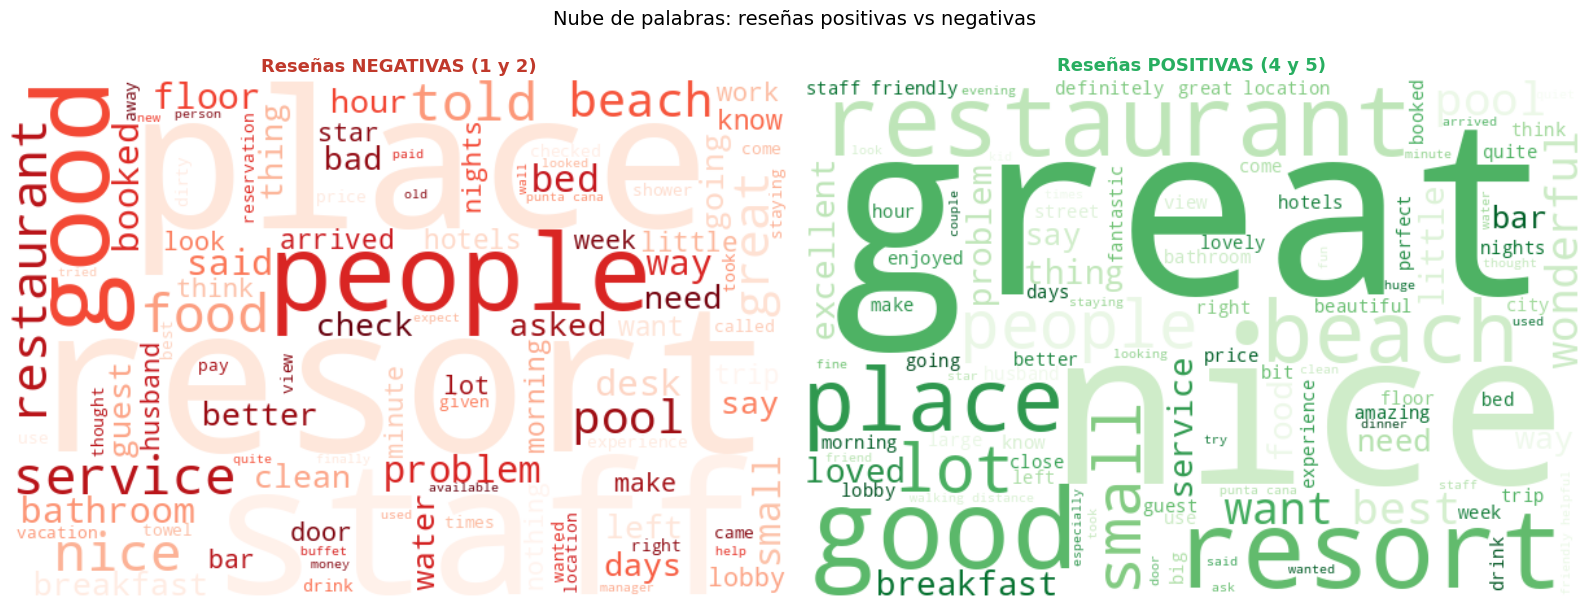


Top-10 palabras NEGATIVAS (1 y 2):
staff(2248), good(2098), service(2044), food(1691), resort(1605), beach(1479), nice(1420), told(1399), people(1378), desk(1374)

Top-10 palabras POSITIVAS (4 y 5):
great(18114), staff(12494), good(12429), nice(9245), location(8709), clean(7302), breakfast(7223), beach(6848), service(6825), food(6151)


In [ ]:
# Agrupar reseñas en positivas y negativas
# Negativas: 1 y 2 | Positivas: 4 y 5 | Se omite 3 por ser ambiguo

texto_negativo = ' '.join([
    df_por_estrella[1],
    df_por_estrella[2]
])

texto_positivo = ' '.join([
    df_por_estrella[4],
    df_por_estrella[5]
])

# Top-10 palabras positivas y negativas
top_negativas = Counter(texto_negativo.split()).most_common(10)
top_positivas = Counter(texto_positivo.split()).most_common(10)

# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Negativas
palabras_neg = [p for p, _ in top_negativas]
conteos_neg  = [c for _, c in top_negativas]
axes[0].barh(palabras_neg[::-1], conteos_neg[::-1], color='#e74c3c')
axes[0].set_title('Top-10 palabras en reseñas NEGATIVAS (1 y 2)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frecuencia')

# Positivas
palabras_pos = [p for p, _ in top_positivas]
conteos_pos  = [c for _, c in top_positivas]
axes[1].barh(palabras_pos[::-1], conteos_pos[::-1], color='#27ae60')
axes[1].set_title('Top-10 palabras en reseñas POSITIVAS (4 y 5)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frecuencia')

plt.tight_layout()
plt.show()

# Nubes de palabras positiva y negativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_negativa = WordCloud(
    width=600, height=400,
    background_color='white',
    colormap='Reds',
    max_words=100,
    random_state=42
).generate(texto_negativo)

wc_positiva = WordCloud(
    width=600, height=400,
    background_color='white',
    colormap='Greens',
    max_words=100,
    random_state=42
).generate(texto_positivo)

axes[0].imshow(wc_negativa, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Reseñas NEGATIVAS (1 y 2)',
                   fontsize=13, fontweight='bold', color='#c0392b')

axes[1].imshow(wc_positiva, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Reseñas POSITIVAS (4 y 5)',
                   fontsize=13, fontweight='bold', color='#27ae60')

plt.suptitle('Nube de palabras: reseñas positivas vs negativas',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen
print("\nTop-10 palabras NEGATIVAS (1 y 2):")
print(', '.join([f'{p}({c})' for p, c in top_negativas]))

print("\nTop-10 palabras POSITIVAS (4 y 5):")
print(', '.join([f'{p}({c})' for p, c in top_positivas]))

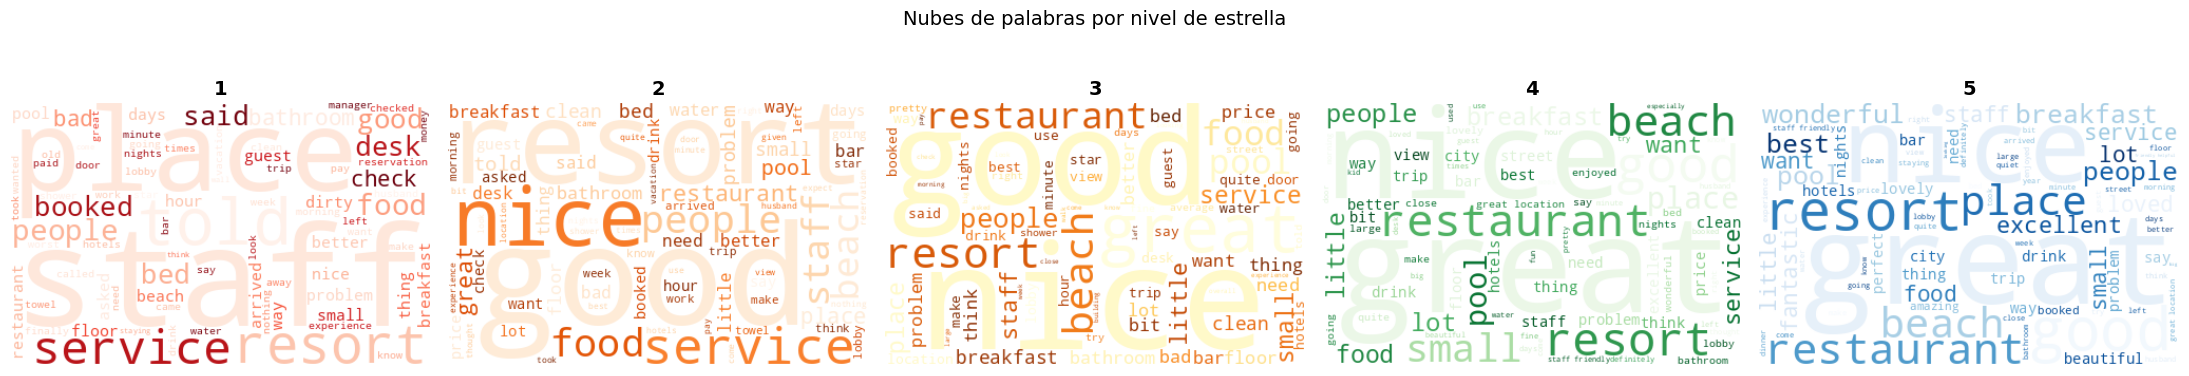

In [ ]:
# Nubes de palabras por nivel de estrella
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

cmaps = {1: 'Reds', 2: 'Oranges', 3: 'YlOrBr', 4: 'Greens', 5: 'Blues'}

for i, estrella in enumerate(range(1, 6)):
    wc = WordCloud(
        width=400, height=250,
        background_color='white',
        colormap=cmaps[estrella],
        max_words=80,
        random_state=42
    ).generate(df_por_estrella[estrella])

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'{estrella}', fontsize=14, fontweight='bold')

plt.suptitle('Nubes de palabras por nivel de estrella', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Experimento 4: Cruce con diccionario de categorías hoteleras

Las palabras clave de cada categoría (limpieza, personal, ubicación, precio, comodidad) las definí basandome en los aspectos de servicio hotelero más estudiados en la literatura de análisis de reseñas online (Ye et al., 2009). Cada término fue seleccionado manualmente verificando que apareciera con frecuencia en el dataset y que tuviera una asociación clara con la categoría correspondiente. Uitilizar este enfoque basado en diccionario permite una interpretación directa y más transparente de los resultados, a diferencia de los modelos de caja negra.

In [ ]:
# Diccionario de categorías hoteleras
# Palabras clave asociadas a cada aspecto del servicio
CATEGORIAS = {
    'limpieza': [
        'clean', 'dirty', 'smell', 'stain', 'dust', 'hygiene',
        'filthy', 'spotless', 'mold', 'odor', 'sanitized',
        'fresh', 'tidy', 'smelly', 'immaculate', 'gross'
    ],
    'personal': [
        'staff', 'service', 'friendly', 'rude', 'helpful', 'polite',
        'unhelpful', 'attentive', 'reception', 'manager', 'professional',
        'courteous', 'kind', 'nasty', 'welcoming', 'front', 'desk'
    ],
    'ubicacion': [
        'location', 'central', 'close', 'far', 'near', 'walking',
        'distance', 'downtown', 'transport', 'airport', 'beach',
        'convenient', 'accessible', 'metro', 'center', 'away'
    ],
    'precio': [
        'price', 'expensive', 'cheap', 'value', 'money', 'overpriced',
        'affordable', 'worth', 'cost', 'budget', 'fee', 'rate',
        'pricey', 'reasonable', 'charge', 'costly'
    ],
    'comodidad': [
        'comfortable', 'bed', 'pillow', 'mattress', 'quiet', 'noisy',
        'sleep', 'air', 'conditioning', 'wifi', 'internet', 'pool',
        'shower', 'bathroom', 'tv', 'amenities', 'spacious', 'small'
    ]
}

# Función para contar menciones de cada categoría en un texto
def contar_categorias(texto, categorias):
    palabras = texto.split()
    conteo = {cat: 0 for cat in categorias}
    for palabra in palabras:
        for cat, keywords in categorias.items():
            if palabra in keywords:
                conteo[cat] += 1
    return conteo

# Calcular frecuencia de cada categoría por nivel de estrella
resultados = {}
for estrella in range(1, 6):
    conteo = contar_categorias(df_por_estrella[estrella], CATEGORIAS)
    # Normalizar por número de reseñas (frecuencia media por reseña)
    n_resenas = (df['Rating'] == estrella).sum()
    resultados[estrella] = {cat: round(count / n_resenas, 4)
                             for cat, count in conteo.items()}

# Crear dataframe para visualización
df_cats = pd.DataFrame(resultados).T  # filas=estrellas, columnas=categorías
df_cats.index = [f'{i}' for i in range(1, 6)]

print("Frecuencia media de menciones por categoría y nivel de estrella:")
print(df_cats.round(4))

Frecuencia media de menciones por categoría y nivel de estrella:
   limpieza  personal  ubicacion  precio  comodidad
1    0.7565    2.5623     1.2505  1.0127     1.9050
2    0.7133    2.6860     1.9777  1.1824     2.4194
3    0.7463    2.2917     2.5481  1.3310     2.4977
4    0.7614    2.3830     2.6541  1.1661     2.3547
5    0.6056    2.5017     2.1070  0.8387     1.8787


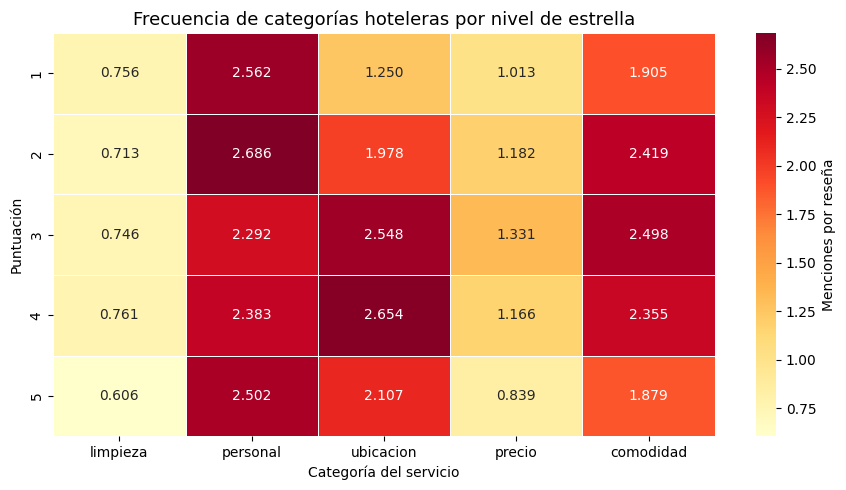

In [ ]:
# Heatmap de categorías por estrella
plt.figure(figsize=(9, 5))
sns.heatmap(
    df_cats,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Menciones por reseña'}
)
plt.title('Frecuencia de categorías hoteleras por nivel de estrella', fontsize=13)
plt.ylabel('Puntuación')
plt.xlabel('Categoría del servicio')
plt.tight_layout()
plt.show()

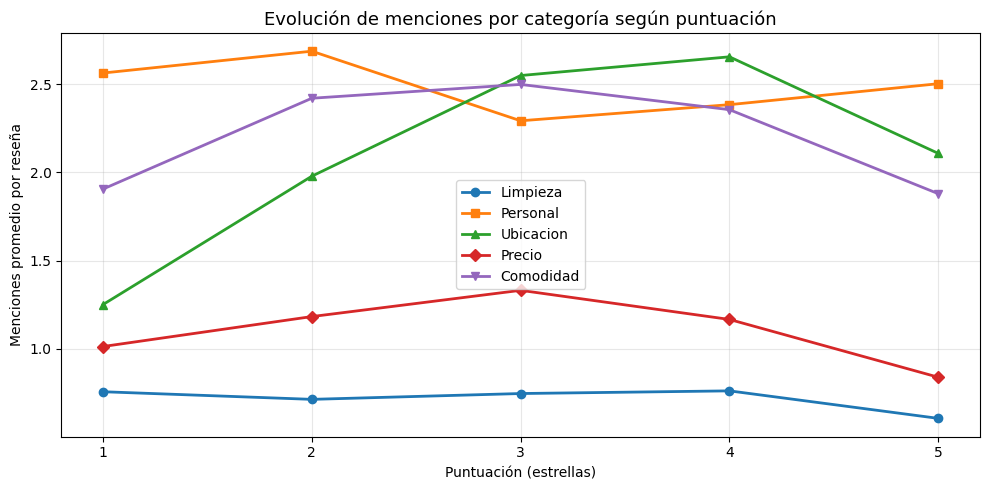

In [ ]:
#  Gráfico de líneas: evolución de cada categoría 1-5
plt.figure(figsize=(10, 5))

markers = ['o', 's', '^', 'D', 'v']
for i, cat in enumerate(CATEGORIAS.keys()):
    plt.plot(df_cats.index, df_cats[cat], marker=markers[i], label=cat.capitalize(), linewidth=2)

plt.title('Evolución de menciones por categoría según puntuación', fontsize=13)
plt.xlabel('Puntuación (estrellas)')
plt.ylabel('Menciones promedio por reseña')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Categoría dominante en reseñas negativas vs positivas
print("\nCategoría que MÁS se menciona en reseñas NEGATIVAS (1 y 2):")
negativas = df_cats.loc[['1', '2']].mean()
print(negativas.sort_values(ascending=False))

print("\nCategoría que MÁS se menciona en reseñas POSITIVAS (4 y 5):")
positivas = df_cats.loc[['4', '5']].mean()
print(positivas.sort_values(ascending=False))


Categoría que MÁS se menciona en reseñas NEGATIVAS (1 y 2):
personal     2.62415
comodidad    2.16220
ubicacion    1.61410
precio       1.09755
limpieza     0.73490
dtype: float64

Categoría que MÁS se menciona en reseñas POSITIVAS (4 y 5):
personal     2.44235
ubicacion    2.38055
comodidad    2.11670
precio       1.00240
limpieza     0.68350
dtype: float64


---
## Experimento 5: Validación manual con 20 reseñas
Tomé 4 reseñas de cada nivel de estrella (20 en total) y verifiqué manualmente si las palabras detectadas tienen coherencia con la categoría asignada.

In [ ]:
def asignar_categoria_dominante(texto, categorias):
    """Asigna la categoría con más menciones en una reseña individual."""
    conteo = contar_categorias(texto, categorias)
    total = sum(conteo.values())
    if total == 0:
        return 'sin_categoria', {}, 0
    cat_dominante = max(conteo, key=conteo.get)
    return cat_dominante, conteo, total

# Seleccionar 4 reseñas de cada nivel (20 en total)
np.random.seed(42)
muestra_ids = []
for estrella in range(1, 6):
    ids = df[df['Rating'] == estrella].index.tolist()
    muestra_ids.extend(np.random.choice(ids, size=4, replace=False))

df_muestra = df.loc[muestra_ids].copy()
df_muestra['review_clean'] = df_muestra['Review'].apply(limpiar_texto)

# Calcular categoría dominante de cada reseña
df_muestra['cat_dominante'] = df_muestra['review_clean'].apply(
    lambda x: asignar_categoria_dominante(x, CATEGORIAS)[0]
)
df_muestra['conteo_cats'] = df_muestra['review_clean'].apply(
    lambda x: asignar_categoria_dominante(x, CATEGORIAS)[1]
)

print(f"Muestra de validación: {len(df_muestra)} reseñas (4 por estrella)")
print("\nResumen:")
print(df_muestra[['Rating','cat_dominante']].value_counts().sort_index())

Muestra de validación: 20 reseñas (4 por estrella)

Resumen:
Rating  cat_dominante
1       personal         3
        precio           1
2       comodidad        2
        personal         1
        ubicacion        1
3       limpieza         1
        personal         1
        precio           1
        ubicacion        1
4       personal         1
        ubicacion        3
5       personal         3
        ubicacion        1
Name: count, dtype: int64


In [ ]:

df_muestra['Coincide_Manual'] = [
    True, False, True, True,   # 1 estrella
    True, True, True, False,   # 2 estrellas
    True, True, False, True,   # 3 estrellas
    True, True, True, True,    # 4 estrellas
    True, False, True, True    # 5 estrellas
]

# Resultados
total_correctas = df_muestra['Coincide_Manual'].sum()
print(f"Coincidencias: {total_correctas}/20 ({total_correctas/20*100:.0f}%)")

# Por nivel
for estrella in range(1, 6):
    sub = df_muestra[df_muestra['Rating'] == estrella]
    n = sub['Coincide_Manual'].sum()
    print(f"{estrella} estrella(s): {n}/4")

Coincidencias: 16/20 (80%)
1 estrella(s): 3/4
2 estrella(s): 3/4
3 estrella(s): 3/4
4 estrella(s): 4/4
5 estrella(s): 3/4


In [ ]:
# Imprimir tabla de validación detallada
print("=" * 85)
print(f"{'ID':>5} | {3} | {'Categoría dominante':^18} | Reseña original (primeros 100 chars)")
print("=" * 85)

for estrella in range(1, 6):
    sub = df_muestra[df_muestra['Rating'] == estrella]
    print(f"\n  ── {estrella} estrella(s) ──")
    for _, row in sub.iterrows():
        resena_corta = row['Review'][:100].replace('\n', ' ')
        print(f"  {row.name:>5} | {row['Rating']:^3} | {row['cat_dominante']:^18} | {resena_corta}...")

   ID | 3 | Categoría dominante | Reseña original (primeros 100 chars)

  ── 1 estrella(s) ──
    453 |  1  |      personal      | old rude blah reason stayed jacuzzi suite, wish stayed, hotel charm lobby, rooms old 50, no fan bath...
   3128 |  1  |      personal      | hated, just got punta cana stayed melia caribe tropical.i want say did site read reviews hotel did n...
   8606 |  1  |      personal      | absolutely horrible stayed 30th august jolly carlton deluxe room best hotel foor payed 130___ exclud...
  12778 |  1  |       precio       | problems way stayed 2 nights, property not bad stayed room squeaky pipes, not pleasant thing woken 6...

  ── 2 estrella(s) ──
   6034 |  2  |     ubicacion      | review doing, time sit write review, reason simple help person stay away barcelo bavaro palace objec...
    892 |  2  |     comodidad      | just n't impressed just completed 13-night stay san francisco business, original reasons decided sta...
  12035 |  2  |     comodidad      | 

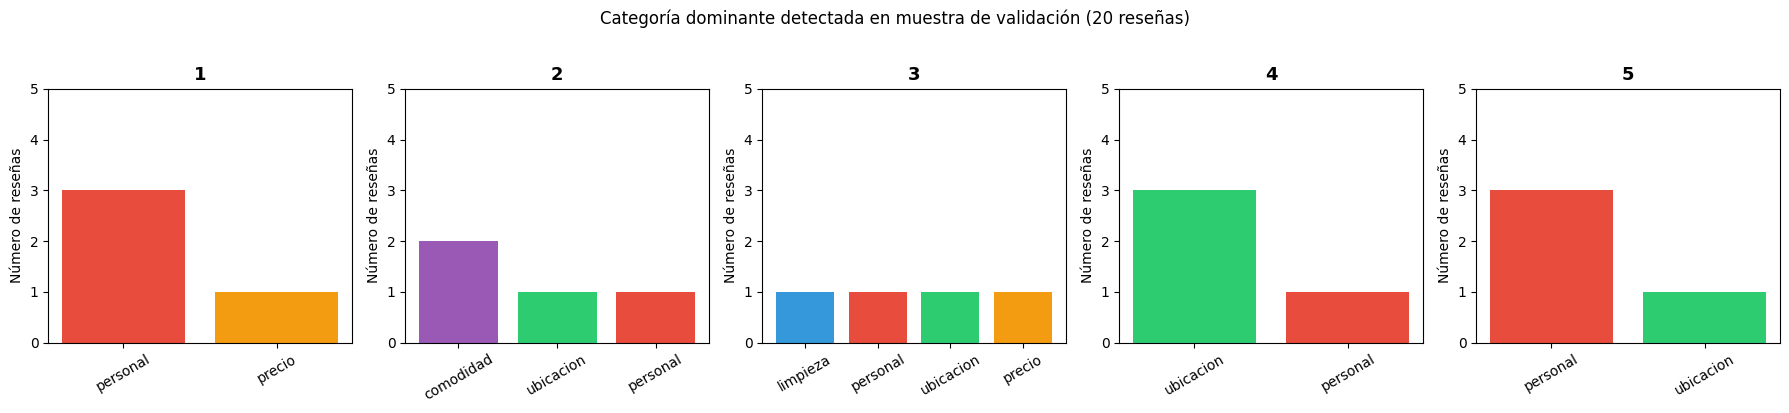

In [ ]:
# Visualizar categorías dominantes en la muestra de validación
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
colores_cat = {
    'limpieza': '#3498db', 'personal': '#e74c3c',
    'ubicacion': '#2ecc71', 'precio': '#f39c12',
    'comodidad': '#9b59b6', 'sin_categoria': '#95a5a6'
}

for i, estrella in enumerate(range(1, 6)):
    sub = df_muestra[df_muestra['Rating'] == estrella]
    conteo_cat = sub['cat_dominante'].value_counts()
    bars = axes[i].bar(
        conteo_cat.index,
        conteo_cat.values,
        color=[colores_cat.get(c, '#95a5a6') for c in conteo_cat.index]
    )
    axes[i].set_title(f'{estrella}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Número de reseñas')
    axes[i].set_ylim(0, 5)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categoría dominante detectada en muestra de validación (20 reseñas)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## Resumen final de resultados

In [ ]:
# Resumen
print('=' * 55)
print('   RESUMEN FINAL — Proyecto Deep Learning')
print('   Identificación de Factores Clave en Reseñas')
print('=' * 55)

print('\n EXPERIMENTO 1 — Baseline (TF-IDF + LR)')
print(f'   Accuracy: {acc_lr*100:.2f}%  | F1-Macro: {f1_lr:.4f}')

print('\n EXPERIMENTO 2 — LSTM con Embeddings')
print(f'   Accuracy: {acc_lstm*100:.2f}%  | F1-Macro: {f1_lstm:.4f}')
supera = ' SÍ supera el baseline' if acc_lstm > acc_lr else 'No supera el baseline'
print(f'   {supera}')

print('\n EXPERIMENTO 3 — Top-10 palabras')
print('   Visualizadas en gráficos de barras y nubes de palabras ')

print('\n EXPERIMENTO 4 — Análisis por categorías')
print(f'   Categoría dominante en reseñas negativas (1-2): {negativas.idxmax().upper()}')
print(f'   Categoría dominante en reseñas positivas (4-5): {positivas.idxmax().upper()}')

print('\n EXPERIMENTO 5 — Validación manual')
print(f'   20 reseñas revisadas manualmente que validan el experimento 4, siendo PERSONAL la categoria más relevante')

print('\n' + '=' * 55)

   RESUMEN FINAL — Proyecto Deep Learning
   Identificación de Factores Clave en Reseñas

 EXPERIMENTO 1 — Baseline (TF-IDF + LR)
   Accuracy: 61.23%  | F1-Macro: 0.5236

 EXPERIMENTO 2 — LSTM con Embeddings
   Accuracy: 60.65%  | F1-Macro: 0.5196
   No supera el baseline

 EXPERIMENTO 3 — Top-10 palabras
   Visualizadas en gráficos de barras y nubes de palabras 

 EXPERIMENTO 4 — Análisis por categorías
   Categoría dominante en reseñas negativas (1-2): PERSONAL
   Categoría dominante en reseñas positivas (4-5): PERSONAL

 EXPERIMENTO 5 — Validación manual
   20 reseñas revisadas manualmente que validan el experimento 4, siendo PERSONAL la categoria más relevante



El modelo LSTM obtuvo un rendimiento mas bajo al baseline TF-IDF + Regresión Logística en términos de accuracy (60.65% vs 61.23%). Este resultado va de la mano con la literatura vista sobre este dataset: estudios previos con el mismo conjunto de datos de TripAdvisor (20.491 reseñas, clasificación 1–5) reportan que modelos clásicos como la Regresión Logística con TF-IDF obtienen resultados competitivos frente a redes neuronales entrenadas desde cero, y que superar ese baseline requiere el uso de embeddings preentrenados como GloVe o modelos transformer como BERT (Emerald Publishing, 2023). En este caso usé GloVe y aún asi no logró obtener mejores resultados que el baseline, al contrario, obtuvo resultados mucho más bajos. Igualmente, lo visto en las literaturas demuestra que con embeddings entrenados desde cero y un dataset de tamaño moderado, el rango real de accuracy está entre el 59% y el 63%, que es un rango bastante cercano a los modelos realizados.

Un gran desafio en este proyecto fue el intentar dismunuir el overfitting, utilicé dropout, bacthnormalitazion, regularización l2, learning rate adaptativo, class weight y aún asi no hubieron mejoras, como mencioné anteriormente esto se debe principalmente al desbalance de clases, porque class weight ajusta la función de perdida pero no modifica la distribución real del dataset.

Es importante resaltar que el criterio de éxito del proyecto no era únicamente predictivo. El objetivo principal era demostrar coherencia semántica en los resultados, es decir, identificar qué categorías del servicio hotelero (limpieza, personal, ubicación, precio, comodidad) caracterizan cada nivel de puntuación. Este objetivo se cumplió adecuadamente mediante los experimentos 3, 4 y 5, que mostraron patrones semánticos consistentes y verificados manualmente.
Esta validación manual significa un aporte propio:
ya que en vez de confiar solamnete en las métricas automáticas, realicé una verificación cualitativamente de que las categorías detectadas tienen
coherencia semántica real con el contenido de las reseñas.
Esto permite tener una perspectiva que los modelos
predictivos por si solos no pueden ofrecer.

**Referencias**

Gholamy, A., Kreinovich, V. and Kosheleva, O. (2018) Why 70/30 or 80/20 Relation between Training and Testing Sets: A Pedagogical Explanation. Departmental Technical Reports (CS).
https://scholarworks.utep.edu/cs_techrep/1209


Manning, C., Raghavan, P. and Schütze, H. (2008) Introduction to Information Retrieval. Cambridge University Press, Cambridge. http://www-nlp.stanford.edu/IR-book
http://dx.doi.org/10.1017/CBO9780511809071

Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. Neural Computation, 9(8), 1735–1780. https://doi.org/10.1162/neco.1997.9.8.1735

Jeffrey Pennington, Richard Socher, and Christopher Manning. 2014. GloVe: Global Vectors for Word Representation. In Proceedings of the 2014 Conference on Empirical Methods in Natural Language Processing (EMNLP), pages 1532–1543, Doha, Qatar. Association for Computational Linguistics.

Ye, Q., Law, R., & Gu, B. (2009). The impact of online user reviews on hotel room sales. International Journal of Hospitality Management, 28(1), 180–182.

